# Credit Card Fraud Detection

# Objective
- The goal of this project is to detect fraudulent credit card transactions using advanced machine learning models and reduce financial fraud risks.
- In this project we will : start from understanding the data preprocess it and EDA 
- Train multiple ML models : Random Forest, XGBoost, Lightgbm, Catboost
- Handeling class imbalance
- Evaluating useful metrices and confusion matrix
- Using SHAP for model explainability
- Deploying the best-performing model

In [ ]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Loading Dataset
df = pd.read_csv('creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Checking Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Our Dataset is clean Already Perfect for furthur Analysis.

In [8]:
# Dropping Time 
df.drop(columns=['Time'], inplace=True)

# Feature Scaling "Amount"
import os 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
os.makedirs("artifacts", exist_ok = True)
df.to_csv("artifacts/1_cleaned_data.csv", index=False)
print("Time column dropped and data saved to 1_cleaned_data.csv")

Time column dropped and data saved to 1_cleaned_data.csv


we didnt need time as it add no value for fraud detection.

# Exploratory Data Analysis (Basic plots)

Class Imbalance Check :-

C:\Users\ANSHAB\AppData\Local\Temp\ipykernel_10804\1608713409.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Class',data = df,  palette= 'Set2')


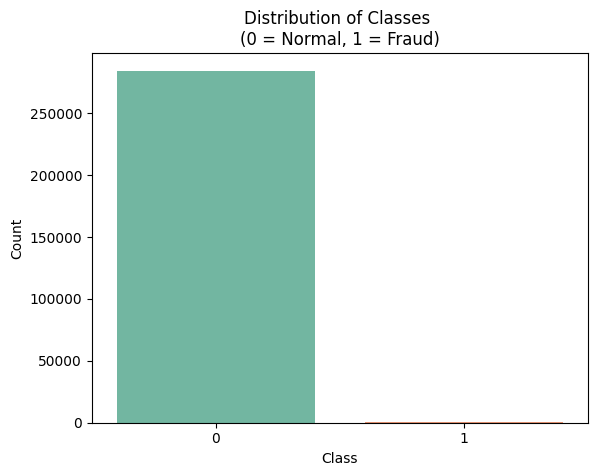

In [9]:
sns.countplot(x ='Class',data = df,  palette= 'Set2')
plt.title("Distribution of Classes \n(0 = Normal, 1 = Fraud)")
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Here it can be seen that Distribution of fraud is very low as compared to Normal.

Transaction Amount Distribution:-

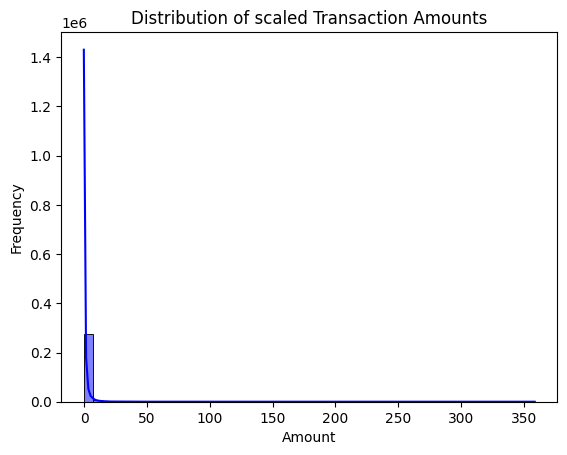

In [10]:
sns.histplot(df['Amount'], bins = 50, kde = True, color = 'blue')
plt.title('Distribution of scaled Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

This long Tail Transaction shows that a very large number of small transaction and fewer larger ones. Most Transaction Amount are concentrated at the lower end of scale.

Amount vs Fraud

C:\Users\ANSHAB\AppData\Local\Temp\ipykernel_10804\2874327184.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'Class', y = 'Amount', data = df, palette='Set2', scale='count', inner='quartile')
C:\Users\ANSHAB\AppData\Local\Temp\ipykernel_10804\2874327184.py:1: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(x = 'Class', y = 'Amount', data = df, palette='Set2', scale='count', inner='quartile')


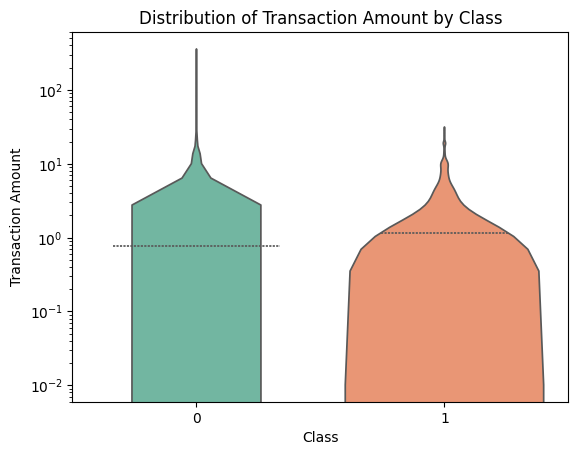

In [11]:
sns.violinplot(x = 'Class', y = 'Amount', data = df, palette='Set2', scale='count', inner='quartile')
plt.title("Distribution of Transaction Amount by Class")
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.yscale('log') # To Handle Outliers
plt.show()

It says that most Frauds are of mid or lower-range amounts.

In [12]:
df['Class'].value_counts()
df['Class'].value_counts(normalize= True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Here 0 -> Fair Transaction
     ,1 -> Unfair Transaction. It can be seen that 99.82 % data is imbalanced and only 0.17% data is balanced We have to handle it before Training, otherwise our models will only predict as non-fraud if we don't fix this.

# Handeling Imbalance Data

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis = 1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE (Synthetic Minority Oversampling)
It will create synthetic samples of the Minority class(fraud cases)to balance the data set.

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

from collections import Counter
print("Before SMOTE:", Counter (y_train))
print("After SMOTE:", Counter (y_train_resampled))

Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE: Counter({0: 227451, 1: 227451})


Now our overall dataset is balanced now, And its ready for model training.

# Model Evaluation 
In this we gonna use our best models which will work great on imbalanced type datasets. In this we will also apply 5-fold cross-validation on the smote-resampled training set using four ensembled models, And evaluate each model using three metrics : Accuracy, F1-Score, ROC AUC.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score,precision_score, f1_score, roc_auc_score,confusion_matrix
# Model training 
rf_model = RandomForestClassifier(n_jobs=-1, class_weight= 'balanced', random_state=42)

# Fit random forest on training data
rf_model.fit(X_train_resampled,y_train_resampled)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob_rf)

# Predict on Test set
rf_y_pred = rf_model.predict(X_test)



# Evaluating metrics
rf_recall = recall_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred)

# Results
print(f"🌴Random Forest Classifier Performance")
print(f"⏪Recall :{rf_recall: .4f}")
print(f"🎯Precision: {rf_precision: .4f}")
print(f"⭐F1-Score : {rf_f1: .4f}")
print(f"Roc-Auc : {rf_roc_auc: .4f}")

cm = confusion_matrix(y_test, rf_y_pred)
print("Confusion Matrix:\n", cm)
print("Sample predicted probabilities:", y_prob_rf[:10])

🌴Random Forest Classifier Performance
⏪Recall : 0.8061
🎯Precision:  0.8681
⭐F1-Score :  0.8360
Roc-Auc :  0.9030
Confusion Matrix:
 [[56852    12]
 [   19    79]]
Sample predicted probabilities: [0.   0.   0.01 0.   0.   0.   0.   0.   0.   0.  ]


In [16]:
print("model features", rf_model.feature_names_in_)

model features ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount']


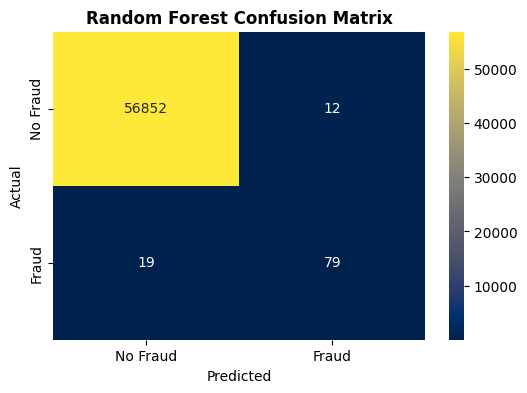

In [17]:
# Random Forest Confusion Matrix

cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='cividis', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("Random Forest Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score

# Model training
xgb_model = XGBClassifier(eval_metric = 'logloss', random_state = 42, objective='binary:logistic')

# Fitting xgboost on training data
xgb_model.fit(X_train_resampled, y_train_resampled)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_xgb)
# Predict on test set
xgb_pred = xgb_model.predict(X_test)

# Evaluating metrics
xgb_recall = recall_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred)

# Results
print(f"XGBoost Classifier Performance:")
print(f"⏪Recall :{xgb_recall: .4f}")
print(f"🎯Precision :{xgb_precision: .4f}")
print(f"⭐F1-Score :{xgb_f1: .4f}")
print(f"Roc-Auc :{xgb_roc_auc :.4f}")
print("Sample predicted probabilities:", y_prob_xgb[:10])

XGBoost Classifier Performance:
⏪Recall : 0.8571
🎯Precision : 0.7304
⭐F1-Score : 0.7887
Roc-Auc :0.9283
Sample predicted probabilities: [4.0385370e-07 6.5879746e-08 9.6196040e-08 1.4811835e-07 4.0742648e-06
 1.4349597e-06 1.2979081e-07 4.6163868e-07 1.0524603e-05 2.3519594e-06]


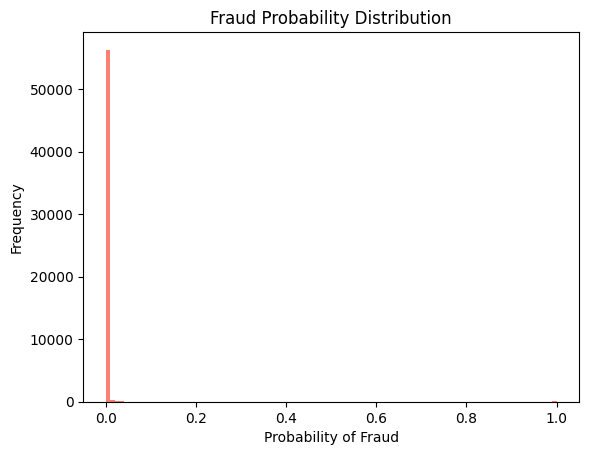

In [19]:
import matplotlib.pyplot as plt

plt.hist(y_prob_xgb, bins=100, color='salmon')
plt.title("Fraud Probability Distribution")
plt.xlabel("Probability of Fraud")
plt.ylabel("Frequency")
plt.show()

In [20]:
print("model features", xgb_model.feature_names_in_)

model features ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount']


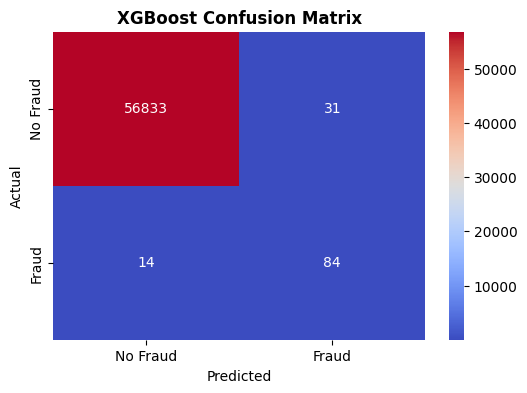

In [ ]:
# XGBoost Confusion Matrix

cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='coolwarm', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("XGBoost Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from lightgbm import LGBMClassifier

gbm_model = LGBMClassifier(objective='binary', metric = 'AUC')

gbm_model.fit(X_train_resampled, y_train_resampled)
gbm_proba = gbm_model.predict_proba(X_test)[:,1]
roc_auc_gbm = roc_auc_score(y_test,gbm_proba)

gbm_pred = gbm_model.predict(X_test)

gbm_recall = recall_score(y_test, gbm_pred)
gbm_precision = precision_score(y_test, gbm_pred)
gbm_f1 = f1_score(y_test, gbm_pred)
gbm_roc_auc = roc_auc_score(y_test, gbm_pred)

print(f"Lightgbm Classifier Performance:")
print(f"Recall :{gbm_recall: .4f}")
print(f"Precision :{gbm_precision:.4f}")
print(f"F1-score :{gbm_f1: .4f}")
print(f"Roc-Auc :{gbm_roc_auc: .4f}")
print(f"sample probabilties:", gbm_proba)

Lightgbm Classifier Performance:
Recall : 0.8571
Precision :0.4641
F1-score : 0.6022
Roc-Auc : 0.9277
sample probabilties: [1.73461373e-04 4.00096590e-04 5.46967102e-04 ... 8.20406542e-05
 2.13722638e-04 4.52422833e-04]


In [23]:
print("model features:",gbm_model.feature_names_in_)

model features: ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount']


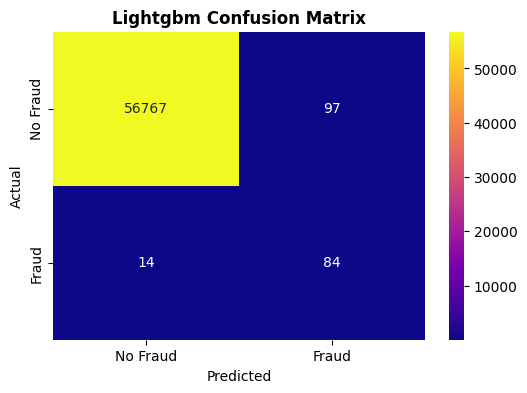

In [ ]:
# Lightgbm Confusion Matrix

cm = confusion_matrix(y_test, gbm_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='plasma', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("Lightgbm Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

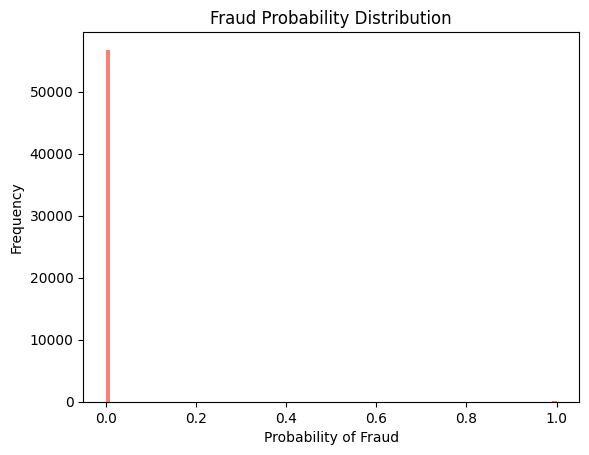

In [31]:
import matplotlib.pyplot as plt

plt.hist(gbm_pred, bins=100, color='salmon')
plt.title("Fraud Probability Distribution")
plt.xlabel("Probability of Fraud")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations= 400, depth=6, verbose=0)

cat_model.fit(X_train_resampled, y_train_resampled)
cat_proba = cat_model.predict_proba(X_test)[:,1]
roc_auc_cat = roc_auc_score(y_test, cat_proba)

cat_pred = cat_model.predict(X_test)

cat_recall = recall_score(y_test,cat_pred)
cat_precision = precision_score(y_test, cat_pred)
cat_f1 = f1_score(y_test,cat_pred)
cat_roc_auc = roc_auc_score(y_test, cat_pred)

print(f"Catboost Classifier Performance:")
print(f"Recall :{cat_recall: .4f}")
print(f"Precision :{cat_precision: .4f}")
print(f"F1-Score :{cat_f1: .4f}")
print(f"Roc-Auc :{cat_roc_auc: .4f}")
print("simple probabilities:",cat_proba)

Catboost Classifier Performance:
Recall : 0.8367
Precision : 0.5734
F1-Score : 0.6805
Roc-Auc : 0.9178
simple probabilities: [4.96711736e-08 1.92291608e-08 1.55656201e-06 ... 3.25600135e-08
 4.74965786e-06 9.49216477e-05]


# HyperParameter Tuning 
For each Model we will tuned  parameter to get out best performing model after our Tuning for all model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)

# Parameter grid for Random Search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

# Randomizing Search with Cross-Validation
rf_random = RandomizedSearchCV(estimator=rf, param_distributions= param_dist, n_iter = 20, cv = 3,scoring='roc_auc', verbose = 2, random_state=42, n_jobs = -1)

# Fit on Resampled Training data
rf_random.fit(X_train_resampled, y_train_resampled)

# Best Parameters
print("Best Parameters:", rf_random.best_params_)

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))



# Evaluation (Test Set)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Dictionary to store results
test_results = {}

# Evaluating each model on Test set
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # As it ranges till 1


    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    
    test_results[name] = {
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Roc-AUC": roc_auc
    }

    print(f"\n {name} Results:")
    print(classification_report(y_test, y_pred))

# Converting DataFrame to Dispalay
test_results_df = pd.DataFrame(test_results).T
print("\n Test Set Evaluation:")
print(test_results_df)

